In [ ]:
import osmnx as ox
import pandas as pd 
import geopandas as gpd
import matplotlib.pyplot as plt 
from shapely.geometry import box


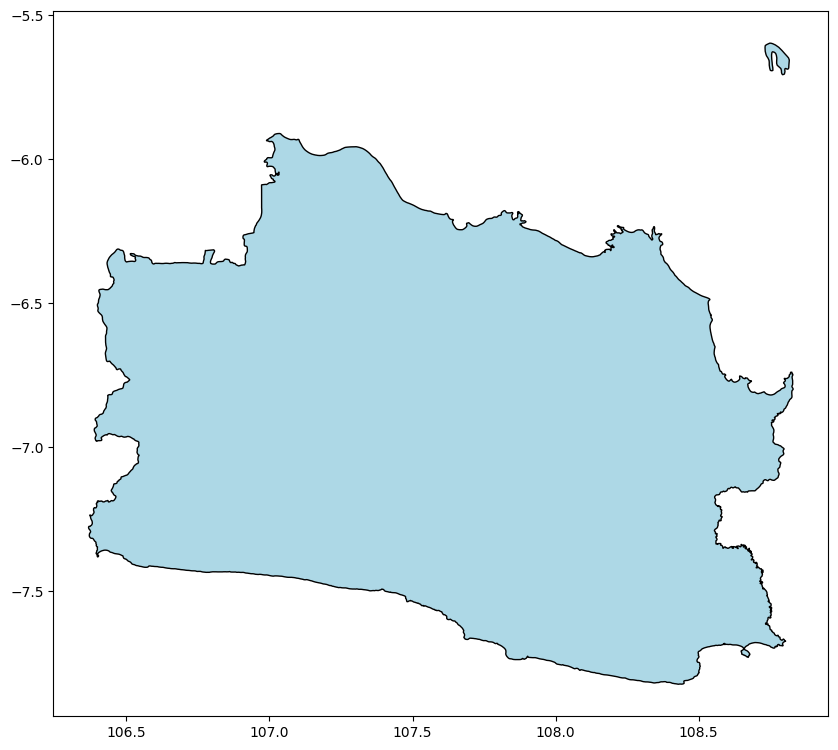

In [ ]:
#Importing requirement dataset

#Load data map Provinsi Jawa Barat

map_path = "indonesia-province.json"
map_df = gpd.read_file(map_path)
map_df.head()

# Visualisasi peta Jawa Barat
jabar_map = map_df[map_df['Propinsi'].str.contains('JAWA BARAT', case=False, na=False)].copy() 
jabar_map = jabar_map.to_crs(epsg=4326)



In [35]:
#Load data kependudukan

data_kependudukan = pd.read_csv('data/kepadatan_penduduk.csv')

df_penduduk_clean = data_kependudukan[data_kependudukan['tahun'] == 2025].copy()
df_penduduk_clean['nama_kabupaten_kota'] = df_penduduk_clean['nama_kabupaten_kota'].str.upper().str.strip()
df_penduduk_clean = df_penduduk_clean[['nama_kabupaten_kota', 'kepadatan_penduduk']]


In [55]:
#Proses pembuatan bounding box untuk wilayah Jawa Barat

utara, selatan, timur, barat = -5.9, -7.8, 108.8, 106.3
bbox_jabar = box(barat, selatan, timur, utara)

categories = {
    "sekolah": {"amenity": "school"},
    "restoran": {"amenity": "restaurant"},
    "pasar": {"amenity": "marketplace"}
}

def get_poi_data(categories_dict, polygon_area):
    all_results = {}

    for name, tags in categories_dict.items():
        try:
            print(f"Lagi ngunduh data {name}..." )

            poi = ox.features_from_polygon(polygon=polygon_area, tags=tags)
            
            if not poi.empty:
                poi = poi[poi.geometry.notnull()].copy()

                poi['lat'] = poi.geometry.centroid.y
                poi['lon'] = poi.geometry.centroid.x
                poi['kategori'] = name

                df_result = poi[['lat', 'lon', 'kategori']].reset_index(drop=True)
                all_results[name] = df_result

                filename = f"data_titik_{name}_jabar.csv"
                df_result.to_csv(filename, index=False)
            else:
                print(f"Tidak ada data ditemukan untuk {name}")
        except Exception as e:
            print(f"Gagal mengunduh data untuk {name}: {e}")
            
    return all_results

download_results = get_poi_data(categories, bbox_jabar)

if download_results:
    df_final = pd.concat(download_results.values(), ignore_index=True)
    df_final.to_csv("data_titik_poi_lengkap_jabar.csv", index=False)
    print("\n" + "="*30)
    print("PROSES SELESAI!")
    print(f"Total data gabungan: {len(df_final)} baris.")
    print("File utama: data_titik_poi_lengkap_jabar.csv")



Lagi ngunduh data sekolah...


c:\Users\Hilmi Mithwa\.pyenv\pyenv-win\versions\3.9.1\lib\site-packages\osmnx\_overpass.py:271: UserWarning: This area is 23 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)
C:\Users\Hilmi Mithwa\AppData\Local\Temp\ipykernel_20592\3810883181.py:24: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  poi['lat'] = poi.geometry.centroid.y
C:\Users\Hilmi Mithwa\AppData\Local\Temp\ipykernel_20592\3810883181.py:25: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  poi['lon'] = poi.geometry.centroid.x
c:\Users\Hilmi Mithwa\.pyenv\pyenv-win\versions\3.

Lagi ngunduh data restoran...


C:\Users\Hilmi Mithwa\AppData\Local\Temp\ipykernel_20592\3810883181.py:24: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  poi['lat'] = poi.geometry.centroid.y
C:\Users\Hilmi Mithwa\AppData\Local\Temp\ipykernel_20592\3810883181.py:25: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  poi['lon'] = poi.geometry.centroid.x
c:\Users\Hilmi Mithwa\.pyenv\pyenv-win\versions\3.9.1\lib\site-packages\osmnx\_overpass.py:271: UserWarning: This area is 23 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


Lagi ngunduh data pasar...

PROSES SELESAI!
Total data gabungan: 20332 baris.
File utama: data_titik_poi_lengkap_jabar.csv


C:\Users\Hilmi Mithwa\AppData\Local\Temp\ipykernel_20592\3810883181.py:24: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  poi['lat'] = poi.geometry.centroid.y
C:\Users\Hilmi Mithwa\AppData\Local\Temp\ipykernel_20592\3810883181.py:25: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  poi['lon'] = poi.geometry.centroid.x


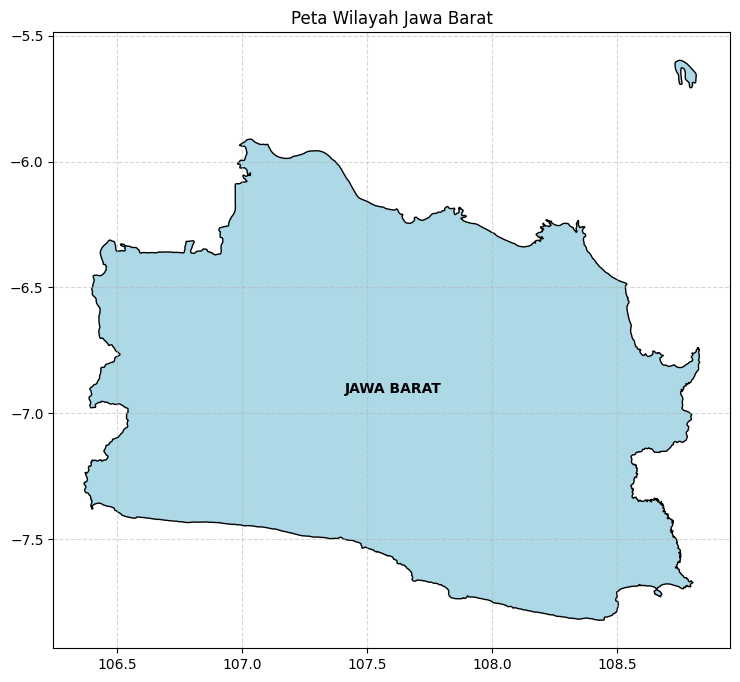

In [ ]:
#memberikan indikator nama dan warna tiap kabupaten/kota pada peta



